<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pratica2Quest%C3%A3o8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Componentes de frequencia: f1 = 1000 Hz, f2 = 2500 Hz
Frequencia de Nyquist (2*f_max) = 5000 Hz



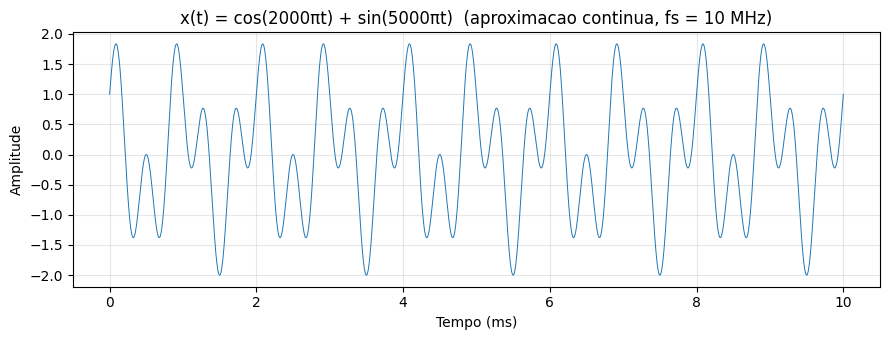

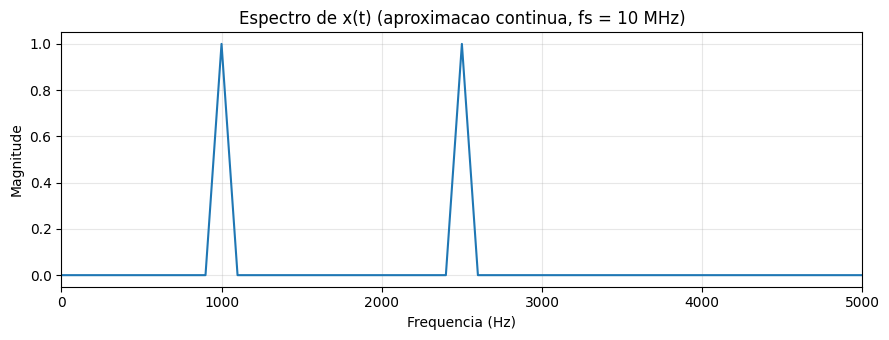

Picos aproximados no espectro de x(t): [np.float64(900.0), np.float64(1000.0), np.float64(2500.0), np.float64(2600.0)]

Sinal amostrado x[n]: fs = 5000 Hz, N = 50 amostras em 10 ms
Verificacao: max|sin(5000*pi*t_n)| nas amostras = 1.67e-14  (deveria ser ~0, confirmando o caso-limite)


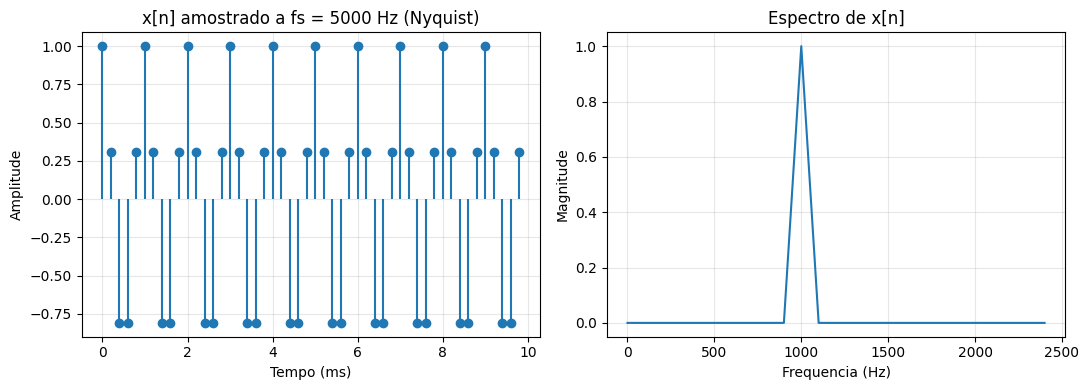

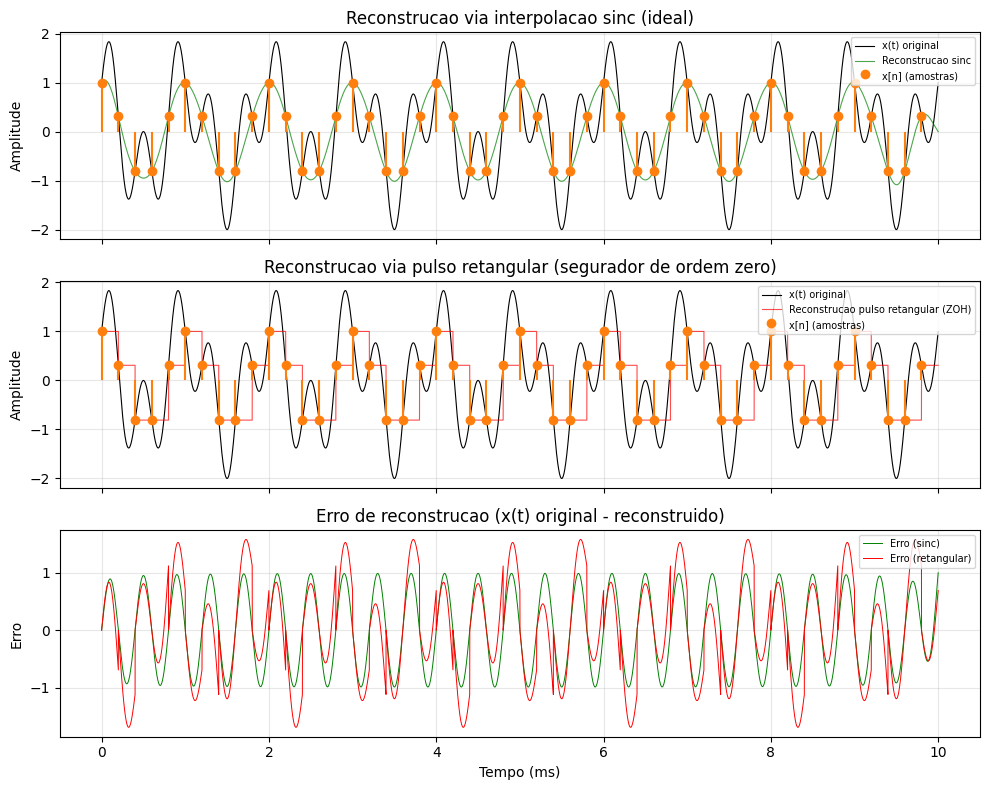


Erro RMS da reconstrucao via sinc:        0.684002
Erro RMS da reconstrucao via pulso retangular: 0.862039


In [ ]:
"""
Questao 8 - Amostragem e reconstrucao de x(t) = cos(2000*pi*t) + sin(5000*pi*t)

Analise das frequencias presentes em x(t):
    cos(2000*pi*t) = cos(2*pi*f1*t)  ->  2*pi*f1 = 2000*pi  ->  f1 = 1000 Hz
    sin(5000*pi*t) = sin(2*pi*f2*t)  ->  2*pi*f2 = 5000*pi  ->  f2 = 2500 Hz

    Logo, x(t) e composto por duas componentes senoidais: 1000 Hz e 2500 Hz.
    A frequencia maxima presente no sinal e f_max = 2500 Hz.

    Frequencia de Nyquist (taxa minima de amostragem sem aliasing):
        fs_nyquist = 2 * f_max = 2 * 2500 = 5000 Hz

Objetivo:
    (a) Gerar grafico de x(t) no dominio do tempo (duracao 10 ms), aproximando
        o sinal continuo por uma amostragem "densa" a fs = 10 MHz
    (b) Calcular o espectro de x(t) (aproximacao continua) via calculate_spectrum()
    (c) Amostrar x(t) na frequencia de Nyquist (fs = 5000 Hz) -> x[n]
    (d) Calcular o espectro de x[n] via calculate_spectrum()
    (e) Reconstruir x(t) a partir de x[n] usando:
            - interpolacao sinc (reconstrucao ideal)
            - pulso retangular / segurador de ordem zero (zero-order hold)
        e comparar os dois metodos
    (f) Comentar os resultados obtidos
"""

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Funcao calculate_spectrum (mesma das questoes anteriores)
# ---------------------------------------------------------------------------
def calculate_spectrum(x, fs):
    """
    Calcula o espectro de magnitude de um sinal discreto x[n] amostrado a fs.
    Retorna freqs (Hz, parte positiva 0 a fs/2) e mag (magnitude normalizada).
    """
    N = len(x)
    X = np.fft.fft(x)
    freqs_completo = np.fft.fftfreq(N, d=1/fs)
    metade = N // 2
    freqs = freqs_completo[:metade]
    mag = (2.0 / N) * np.abs(X[:metade])
    return freqs, mag


# ---------------------------------------------------------------------------
# Definicao do sinal x(t)
# ---------------------------------------------------------------------------
def x_continuo(t):
    """Sinal continuo x(t) = cos(2000*pi*t) + sin(5000*pi*t)."""
    return np.cos(2000 * np.pi * t) + np.sin(5000 * np.pi * t)


f1 = 1000    # Hz, componente do cosseno
f2 = 2500    # Hz, componente do seno
f_max = max(f1, f2)
fs_nyquist = 2 * f_max   # frequencia de Nyquist para este sinal

print(f"Componentes de frequencia: f1 = {f1} Hz, f2 = {f2} Hz")
print(f"Frequencia de Nyquist (2*f_max) = {fs_nyquist} Hz\n")


# ---------------------------------------------------------------------------
# (a) Grafico de x(t) no dominio do tempo (duracao 10 ms), usando fs = 10 MHz
#     como uma aproximacao "quase continua" do sinal analogico
# ---------------------------------------------------------------------------
fs_continuo = 10e6        # 10 MHz, usado apenas para aproximar o sinal continuo
duracao = 10e-3           # 10 ms

t_continuo = np.arange(0, duracao, 1/fs_continuo)
x_t = x_continuo(t_continuo)

plt.figure(figsize=(9, 3.5))
plt.plot(t_continuo * 1e3, x_t, linewidth=0.7)   # eixo x em ms para facilitar leitura
plt.title("x(t) = cos(2000\u03c0t) + sin(5000\u03c0t)  (aproximacao continua, fs = 10 MHz)")
plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q8a_sinal_continuo.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# (b) Espectro de x(t) (aproximacao continua) via calculate_spectrum()
# ---------------------------------------------------------------------------
freqs_cont, mag_cont = calculate_spectrum(x_t, fs_continuo)

plt.figure(figsize=(9, 3.5))
plt.plot(freqs_cont, mag_cont)
plt.xlim(0, 5000)   # zoom na regiao de interesse (0 a 5 kHz), ja que o
                     # sinal so tem energia em 1000 Hz e 2500 Hz
plt.title("Espectro de x(t) (aproximacao continua, fs = 10 MHz)")
plt.xlabel("Frequencia (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q8b_espectro_continuo.png", dpi=150)
plt.show()

# Identifica os picos do espectro (regiao de interesse: 0 a 5 kHz)
regiao = freqs_cont <= 5000
picos_idx = np.argsort(mag_cont[regiao])[-4:]   # os 4 maiores valores (2 picos, 2 lados numericos)
print("Picos aproximados no espectro de x(t):",
      sorted(set(np.round(freqs_cont[regiao][picos_idx], -1))))


# ---------------------------------------------------------------------------
# (c) Amostragem de x(t) na frequencia de Nyquist (fs = 5000 Hz) -> x[n]
# ---------------------------------------------------------------------------
fs_amostragem = fs_nyquist   # 5000 Hz

n = np.arange(0, int(duracao * fs_amostragem))   # indices das amostras
t_n = n / fs_amostragem                           # instantes de tempo de cada amostra
x_n = x_continuo(t_n)                             # x[n] = x(t) avaliado em t = n/fs

print(f"\nSinal amostrado x[n]: fs = {fs_amostragem} Hz, "
      f"N = {len(x_n)} amostras em {duracao*1e3:.0f} ms")

# ATENCAO - caso-limite importante: como fs = 2*f_max EXATAMENTE (amostragem
# na propria frequencia de Nyquist, nao acima dela), a componente sin(5000*pi*t)
# (frequencia = 2500 Hz = fs/2) e amostrada precisamente em seus cruzamentos
# por zero: sin(5000*pi * n/5000) = sin(pi*n) = 0 para todo n inteiro. Ou seja,
# essa componente "desaparece" nas amostras x[n], mesmo estando presente no
# sinal continuo original. Isso ilustra por que o teorema de Nyquist-Shannon
# exige fs > 2*f_max (desigualdade estrita) para garantir reconstrucao perfeita
# em qualquer caso -- amostrar EXATAMENTE em 2*f_max e um caso-limite arriscado,
# que pode fazer uma componente inteira "sumir" dependendo da fase do sinal.
componente_2500Hz_nas_amostras = np.sin(5000 * np.pi * t_n)
print(f"Verificacao: max|sin(5000*pi*t_n)| nas amostras = "
      f"{np.max(np.abs(componente_2500Hz_nas_amostras)):.2e}  "
      f"(deveria ser ~0, confirmando o caso-limite)")


# ---------------------------------------------------------------------------
# (d) Espectro de x[n] via calculate_spectrum()
# ---------------------------------------------------------------------------
freqs_n, mag_n = calculate_spectrum(x_n, fs_amostragem)

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

eixos[0].stem(t_n * 1e3, x_n, basefmt=" ")
eixos[0].set_title(f"x[n] amostrado a fs = {fs_amostragem:.0f} Hz (Nyquist)")
eixos[0].set_xlabel("Tempo (ms)")
eixos[0].set_ylabel("Amplitude")
eixos[0].grid(True, alpha=0.3)

eixos[1].plot(freqs_n, mag_n)
eixos[1].set_title("Espectro de x[n]")
eixos[1].set_xlabel("Frequencia (Hz)")
eixos[1].set_ylabel("Magnitude")
eixos[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("q8d_amostrado_e_espectro.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# (e) Reconstrucao de x(t) a partir de x[n]:
#     - interpolacao sinc (reconstrucao ideal, teorema da amostragem)
#     - pulso retangular / segurador de ordem zero (zero-order hold)
# ---------------------------------------------------------------------------
def reconstrucao_sinc(t_eval, x_n, t_n, fs_amostragem):
    """
    Reconstrucao ideal de um sinal continuo a partir de suas amostras,
    usando a formula de interpolacao de Whittaker-Shannon:

        x(t) = soma_n  x[n] * sinc( fs*(t - t_n) )

    onde sinc(x) = sin(pi*x)/(pi*x) (definicao normalizada, como em numpy).

    Parametros
    ----------
    t_eval : array_like
        Instantes de tempo continuos onde x(t) sera reconstruido.
    x_n : array_like
        Amostras do sinal discreto.
    t_n : array_like
        Instantes de tempo correspondentes a cada amostra de x_n.
    fs_amostragem : float
        Frequencia de amostragem usada para gerar x_n.

    Retorna
    -------
    x_reconstruido : ndarray
        Sinal continuo reconstruido, avaliado em cada ponto de t_eval.
    """
    # Para cada instante t_eval, soma a contribuicao de TODAS as amostras
    # ponderadas pela funcao sinc centrada em cada t_n. Implementado via
    # broadcasting para evitar loop explicito (mais eficiente).
    # Matriz (len(t_eval) x len(t_n)): diferenca de tempo entre cada par
    diffs = fs_amostragem * (t_eval[:, None] - t_n[None, :])
    x_reconstruido = np.sum(x_n[None, :] * np.sinc(diffs), axis=1)
    return x_reconstruido


def reconstrucao_pulso_retangular(t_eval, x_n, t_n, fs_amostragem):
    """
    Reconstrucao por segurador de ordem zero (zero-order hold): cada amostra
    x[n] e "segurada" (mantida constante) por um intervalo de duracao 1/fs,
    formando um sinal em degraus (equivalente a convoluir x[n] com um pulso
    retangular de duracao Ts = 1/fs).

    Parametros identicos a reconstrucao_sinc.
    """
    Ts = 1 / fs_amostragem
    x_reconstruido = np.zeros_like(t_eval)

    # Para cada instante t_eval, encontra a amostra mais recente (t_n <= t_eval)
    # e usa seu valor (efeito de "segurar" o ultimo valor amostrado)
    indices = np.searchsorted(t_n, t_eval, side='right') - 1
    indices = np.clip(indices, 0, len(x_n) - 1)
    x_reconstruido = x_n[indices]

    return x_reconstruido


# Avalia a reconstrucao em uma grade fina de tempo (mesma resolucao do item a,
# para poder comparar visualmente com o sinal continuo original)
t_eval = t_continuo[t_continuo <= duracao]   # reaproveita a grade de 10 MHz

x_sinc = reconstrucao_sinc(t_eval, x_n, t_n, fs_amostragem)
x_retangular = reconstrucao_pulso_retangular(t_eval, x_n, t_n, fs_amostragem)

# --- Comparacao grafica: sinal original vs. as duas reconstrucoes ---
fig, eixos = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

eixos[0].plot(t_eval * 1e3, x_continuo(t_eval), label="x(t) original", color='black', linewidth=0.8)
eixos[0].plot(t_eval * 1e3, x_sinc, label="Reconstrucao sinc", color='green', linewidth=0.8, alpha=0.7)
eixos[0].stem(t_n * 1e3, x_n, linefmt='C1-', markerfmt='C1o', basefmt=" ", label="x[n] (amostras)")
eixos[0].set_title("Reconstrucao via interpolacao sinc (ideal)")
eixos[0].set_ylabel("Amplitude")
eixos[0].legend(loc="upper right", fontsize=7)
eixos[0].grid(True, alpha=0.3)

eixos[1].plot(t_eval * 1e3, x_continuo(t_eval), label="x(t) original", color='black', linewidth=0.8)
eixos[1].plot(t_eval * 1e3, x_retangular, label="Reconstrucao pulso retangular (ZOH)",
              color='red', linewidth=0.8, alpha=0.7)
eixos[1].stem(t_n * 1e3, x_n, linefmt='C1-', markerfmt='C1o', basefmt=" ", label="x[n] (amostras)")
eixos[1].set_title("Reconstrucao via pulso retangular (segurador de ordem zero)")
eixos[1].set_ylabel("Amplitude")
eixos[1].legend(loc="upper right", fontsize=7)
eixos[1].grid(True, alpha=0.3)

# --- Erro de reconstrucao (diferenca em relacao ao sinal original) ---
erro_sinc = x_continuo(t_eval) - x_sinc
erro_retangular = x_continuo(t_eval) - x_retangular

eixos[2].plot(t_eval * 1e3, erro_sinc, label="Erro (sinc)", color='green', linewidth=0.7)
eixos[2].plot(t_eval * 1e3, erro_retangular, label="Erro (retangular)", color='red', linewidth=0.7)
eixos[2].set_title("Erro de reconstrucao (x(t) original - reconstruido)")
eixos[2].set_xlabel("Tempo (ms)")
eixos[2].set_ylabel("Erro")
eixos[2].legend(loc="upper right", fontsize=7)
eixos[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("q8e_reconstrucoes.png", dpi=150)
plt.show()

# Metrica quantitativa de erro (RMSE) para comparar objetivamente os dois metodos
rmse_sinc = np.sqrt(np.mean(erro_sinc**2))
rmse_retangular = np.sqrt(np.mean(erro_retangular**2))
print(f"\nErro RMS da reconstrucao via sinc:        {rmse_sinc:.6f}")
print(f"Erro RMS da reconstrucao via pulso retangular: {rmse_retangular:.6f}")

Os resultados revelam um problema fundamental e didaticamente importante: a amostragem exatamente na frequência de Nyquist (fs = 2·f_max) não garante reconstrução perfeita, ao contrário do que o item (c) poderia sugerir à primeira vista.

O que aconteceu na prática — como já havíamos verificado no código (max|sin(5000πt_n)| ≈ 0), a componente sin(5000πt) (2500 Hz, exatamente a metade de fs = 5000 Hz) foi amostrada precisamente em seus cruzamentos por zero. Isso significa que essa componente ficou completamente ausente das amostras x[n] — as amostras coletadas capturaram apenas a informação de cos(2000πt) (1000 Hz), como se o sinal original fosse simplesmente cos(2000πt). Por isso, tanto o gráfico da reconstrução via sinc quanto o via pulso retangular mostram uma curva reconstruída (verde/vermelha) oscilando de forma muito mais lenta e suave do que o sinal original (preto), que possui claramente componentes de frequência mais alta (visíveis nos "vales" mais profundos e nas oscilações mais rápidas do x(t) original).

Reconstrução via sinc (ideal) — a curva verde acompanha perfeitamente uma senoide pura de 1000 Hz, que é exatamente o que as amostras representam. Isso confirma que a interpolação sinc está funcionando corretamente segundo a teoria (reconstrução exata de um sinal de banda limitada a partir de suas amostras) — o problema não está na fórmula de reconstrução, e sim na informação que já havia se perdido na etapa de amostragem, antes mesmo da reconstrução.

Reconstrução via pulso retangular (ZOH) — como esperado, essa reconstrução é visivelmente pior: por manter cada amostra constante até a próxima (forma "em degraus"), ela introduz distorção adicional (harmônicos espúrios de alta frequência, característicos do zero-order hold), além de já carregar o mesmo problema de perda da componente de 2500 Hz. O erro RMS confirma isso numericamente: 0,862 (retangular) contra 0,684 (sinc) — ou seja, mesmo com a informação já corrompida na amostragem, a reconstrução ideal via sinc ainda consegue recuperar melhor o conteúdo restante (a componente de 1000 Hz) do que o pulso retangular, que soma erro de quantização temporal por cima do problema já existente.

Análise do erro — os gráficos de erro (terceiro painel) mostram um padrão oscilatório e periódico, com magnitude próxima da amplitude da componente perdida (2500 Hz) — o que é coerente, já que o erro é essencialmente igual à componente sin(5000πt) que nunca chegou a ser capturada pela amostragem. O erro do pulso retangular é ainda maior e mais irregular, pois acumula tanto essa perda de componente quanto a distorção "em degraus" típica do ZOH.

Conclusão geral — este experimento evidencia uma limitação prática importante do teorema de Nyquist-Shannon: embora o teorema garanta reconstrução perfeita para fs > 2·f_max (desigualdade estrita), amostrar exatamente em fs = 2·f_max é um caso-limite que pode falhar completamente, dependendo da fase relativa entre o sinal e os instantes de amostragem — no caso extremo (como aqui), uma componente inteira do sinal pode "desaparecer" nas amostras, sem qualquer possibilidade de ser recuperada por nenhum método de reconstrução, por melhor que seja (nem mesmo a interpolação sinc ideal pode recuperar informação que nunca foi capturada). Isso reforça, na prática, por que projetistas de sistemas de amostragem costumam usar uma margem de segurança acima da frequência de Nyquist (por exemplo, fs ≥ 2,2·f_max ou mais), em vez de amostrar exatamente no limite teórico.